In [1]:
import os
from datetime import datetime
import uuid, base64

import httpx
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage, ToolMessage
from langchain_core.tools import InjectedToolArg, InjectedToolCallId, tool
from langgraph.prebuilt import InjectedState
from langgraph.types import Command
from markdownify import markdownify
from pydantic import BaseModel, Field
from tavily import TavilyClient
from typing_extensions import Annotated, Literal

from deep_agents_from_scratch.prompts import SUMMARIZE_WEB_SEARCH
from langchain_ollama import ChatOllama
from deep_agents_from_scratch.state import DeepAgentState
from dotenv import load_dotenv

load_dotenv(os.path.join("..", ".env"), override=True)

%load_ext autoreload
%autoreload 2

In [2]:
%%writefile ../src/deep_agents_from_scratch/research_tools.py
"""Research Tools.

This module provides search and content processing utilities for the research agent,
including web search capabilities and content summarization tools.
"""
# Summarization model 

summarization_model = init_chat_model(model="ollama:llama3.1:8b", temperature=0.3)
tavily_client = TavilyClient(api_key="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")

class Summary(BaseModel):
    """Schema for webpage content summarization."""
    filename: str = Field(description="Name of the file to store.")
    summary: str = Field(description="Key learnings from the webpage.")

def get_today_str() -> str:
    """Get current date in a human-readable format."""
    return datetime.now().strftime("%a %b %-d, %Y")

def run_tavily_search(
    search_query: str, 
    max_results: int = 1, 
    topic: Literal["general", "news", "finance"] = "general", 
    include_raw_content: bool = True, 
) -> dict:
    """Perform search using Tavily API for a single query.

    Args:
        search_query: Search query to execute
        max_results: Maximum number of results per query
        topic: Topic filter for search results
        include_raw_content: Whether to include raw webpage content

    Returns:
        Search results dictionary
    """
    result = tavily_client.search(
        search_query,
        max_results=max_results,
        include_raw_content=include_raw_content,
        topic=topic,
        search_depth="advanced",
    )

    return result

def summarize_webpage_content(webpage_content: str) -> Summary:
    """Summarize webpage content using the configured summarization model.
    
    Args:
        webpage_content: Raw webpage content to summarize
        
    Returns:
        Summary object with filename and summary
    """
    try:
        # Set up structured output model for summarization. Class Summary has filename and summary fields.
        structured_model = summarization_model.with_structured_output(Summary)
        
        # Generate summary
        summary_and_filename = structured_model.invoke([
            HumanMessage(content=SUMMARIZE_WEB_SEARCH.format(
                webpage_content=webpage_content, 
                date=get_today_str()
            ))
        ])
        
        return summary_and_filename
        
    except Exception:
        # Return a basic summary object on failure
        return Summary(
            filename="search_result.md",
            summary=webpage_content[:1000] + "..." if len(webpage_content) > 1000 else webpage_content
        )

def process_search_results(results: dict) -> list[dict]:
    """Process search results by summarizing content where available.
    
    Args:
        results: Tavily search results dictionary
        
    Returns:
        List of processed results with summaries
    """
    processed_results = []

    # Create a client for HTTP requests
    HTTPX_CLIENT = httpx.Client()
    
    for result in results.get('results', []):
        
        # Get url 
        url = result['url']
        
        # Read url
        response = HTTPX_CLIENT.get(url)

        if response.status_code == 200:
            # Convert HTML to markdown
            raw_content = markdownify(response.text)
            summary_obj = summarize_webpage_content(raw_content)
        else:
            # Use Tavily's generated summary
            raw_content = result.get('raw_content', '')
            summary_obj = Summary(
                filename="URL_error.md",
                summary=result.get('content', 'Error reading URL; try another search.')
            )
        
        # uniquify file names
        uid = base64.urlsafe_b64encode(uuid.uuid4().bytes).rstrip(b"=").decode("ascii")[:8]
        name, ext = os.path.splitext(summary_obj.filename)
        summary_obj.filename = f"{name}_{uid}{ext}"

        processed_results.append({
            'url': result['url'],
            'title': result['title'],
            'summary': summary_obj.summary,
            'filename': summary_obj.filename,
            'raw_content': raw_content,
        })
    
    return processed_results

@tool(parse_docstring=True)
def tavily_search(
    query: str,
    state: Annotated[DeepAgentState, InjectedState],
    tool_call_id: Annotated[str, InjectedToolCallId],
    max_results: Annotated[int, InjectedToolArg] = 1,
    topic: Annotated[Literal["general", "news", "finance"], InjectedToolArg] = "general",
) -> Command:
    """Search web and save detailed results to files while returning minimal context.

    Performs web search and saves full content to files for context offloading.
    Returns only essential information to help the agent decide on next steps.

    Args:
        query: Search query to execute
        state: Injected agent state for file storage
        tool_call_id: Injected tool call identifier
        max_results: Maximum number of results to return (default: 1)
        topic: Topic filter - 'general', 'news', or 'finance' (default: 'general')

    Returns:
        Command that saves full results to files and provides minimal summary
    """
    # Execute search
    search_results = run_tavily_search(
        query,
        max_results=max_results,
        topic=topic,
        include_raw_content=True,
    ) 

    # Process and summarize results
    processed_results = process_search_results(search_results)
    
    # Save each result to a file and prepare summary
    files = state.get("files", {})
    saved_files = []
    summaries = []
    
    for i, result in enumerate(processed_results):
        # Use the AI-generated filename from summarization
        filename = result['filename']
        
        # Create file content with full details
        file_content = f"""# Search Result: {result['title']}

            **URL:** {result['url']}
            **Query:** {query}
            **Date:** {get_today_str()}

            ## Summary
            {result['summary']}

            ## Raw Content
            {result['raw_content'] if result['raw_content'] else 'No raw content available'}
            """
        
        files[filename] = file_content
        saved_files.append(filename)
        summaries.append(f"- {filename}: {result['summary']}...")
    
    # Create minimal summary for tool message - focus on what was collected
    summary_text = f"""🔍 Found {len(processed_results)} result(s) for '{query}':

        {chr(10).join(summaries)}

        Files: {', '.join(saved_files)}
        💡 Use read_file() to access full details when needed."""

    return Command(
        update={
            "files": files,
            "messages": [
                ToolMessage(summary_text, tool_call_id=tool_call_id)
            ],
        }
    )

@tool(parse_docstring=True)
def think_tool(reflection: str) -> str:
    """Tool for strategic reflection on research progress and decision-making.

    Use this tool after each search to analyze results and plan next steps systematically.
    This creates a deliberate pause in the research workflow for quality decision-making.

    When to use:
    - After receiving search results: What key information did I find?
    - Before deciding next steps: Do I have enough to answer comprehensively?
    - When assessing research gaps: What specific information am I still missing?
    - Before concluding research: Can I provide a complete answer now?
    - How complex is the question: Have I reached the number of search limits?

    Reflection should address:
    1. Analysis of current findings - What concrete information have I gathered?
    2. Gap assessment - What crucial information is still missing?
    3. Quality evaluation - Do I have sufficient evidence/examples for a good answer?
    4. Strategic decision - Should I continue searching or provide my answer?

    Args:
        reflection: Your detailed reflection on research progress, findings, gaps, and next steps

    Returns:
        Confirmation that reflection was recorded for decision-making
    """
    return f"Reflection recorded: {reflection}"

Overwriting ../src/deep_agents_from_scratch/research_tools.py


## Deep Agent

Now, we can just apply all of our prior learnings: 

* We'll give the researcher a `think_tool` and our `search_tool` above.
* We'll give our parent agent `file tools`, a `think_tool`, and a `task` tool. 

In [3]:
from datetime import datetime

from IPython.display import Image, display
from langchain.chat_models import init_chat_model
from langgraph.prebuilt import create_react_agent
from utils import show_prompt, stream_agent

from deep_agents_from_scratch.file_tools import ls, read_file, write_file
from deep_agents_from_scratch.prompts import (
    FILE_USAGE_INSTRUCTIONS,
    RESEARCHER_INSTRUCTIONS,
    SUBAGENT_USAGE_INSTRUCTIONS,
    TODO_USAGE_INSTRUCTIONS,
)
from deep_agents_from_scratch.research_tools import tavily_search, think_tool, get_today_str
from deep_agents_from_scratch.state import DeepAgentState
from deep_agents_from_scratch.task_tool import _create_task_tool

from deep_agents_from_scratch.todo_tools import write_todos, read_todos

# Create agent using create_react_agent directly
model = init_chat_model(model="ollama:qwen3:8b", temperature=0.2)

# Limits
max_concurrent_research_units = 2
max_researcher_iterations = 3

# Tools
sub_agent_tools = [tavily_search, think_tool]
built_in_tools = [ls, read_file, write_file, write_todos, read_todos, think_tool]

# Create research sub-agent
research_sub_agent = {
    "name": "research-agent",
    "description": "Delegate research to the sub-agent researcher. Only give this researcher one topic at a time.",
    "prompt": RESEARCHER_INSTRUCTIONS.format(date=get_today_str()),
    "tools": ["tavily_search", "think_tool"],
}

# Create task tool to delegate tasks to sub-agents
task_tool = _create_task_tool(
    sub_agent_tools, [research_sub_agent], model, DeepAgentState
)

delegation_tools = [task_tool]
all_tools = sub_agent_tools + built_in_tools + delegation_tools  # search available to main agent for trivial cases

# Build prompt
SUBAGENT_INSTRUCTIONS = SUBAGENT_USAGE_INSTRUCTIONS.format(
    max_concurrent_research_units=max_concurrent_research_units,
    max_researcher_iterations=max_researcher_iterations,
    date=datetime.now().strftime("%a %b %-d, %Y"),
)

In [4]:
show_prompt(RESEARCHER_INSTRUCTIONS)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  You are a research assistant conducting research on the user's input topic. For context, today's date is       │
│  {date}.                                                                                                        │
│                                                                                                                 │
│  <Task>                                                                                                         │
│  Your job is to use tools to gather information about the user's input topic.                                   │
│  You can use any of the tools provided to you to find resources that can help answer the research question.     │
│  You can call these tools in series or in parallel, your research is conducted in a tool-calling loop.          │
│  </Task>                                                                                                        │
│                                                                                                                 │
│  <Available Tools>                                                                                              │
│  You have access to two main tools:                                                                             │
│  1. **tavily_search**: For conducting web searches to gather information                                        │
│  2. **think_tool**: For reflection and strategic planning during research                                       │
│                                                                                                                 │
│  **CRITICAL: Use think_tool after each search to reflect on results and plan next steps**                       │
│  </Available Tools>                                                                                             │
│                                                                                                                 │
│  <Instructions>                                                                                                 │
│  Think like a human researcher with limited time. Follow these steps:                                           │
│                                                                                                                 │
│  1. **Read the question carefully** - What specific information does the user need?                             │
│  2. **Start with broader searches** - Use broad, comprehensive queries first                                    │
│  3. **After each search, pause and assess** - Do I have enough to answer? What's still missing?                 │
│  4. **Execute narrower searches as you gather information** - Fill in the gaps                                  │
│  5. **Stop when you can answer confidently** - Don't keep searching for perfection                              │
│  </Instructions>                                                                                                │
│                                                                                                                 │
│  <Hard Limits>                                                                                                  │
│  **Tool Call Budgets** (Prevent excessive searching):                                                           │
│  - **Simple queries**: Use 1-2 search tool calls maximum                                                        │
│  - **Normal queries**: Use 2-3 search tool calls maximum                                                        │
│  - **Very Complex queries**: Use up to 5 search tool calls maximum                                              │
│  - **Always stop**: After 5 search tool calls if you c

In [5]:
INSTRUCTIONS = (
    "# TODO MANAGEMENT\n"
    + TODO_USAGE_INSTRUCTIONS
    + "\n\n"
    + "=" * 80
    + "\n\n"
    + "# FILE SYSTEM USAGE\n"
    + FILE_USAGE_INSTRUCTIONS
    + "\n\n"
    + "=" * 80
    + "\n\n"
    + "# SUB-AGENT DELEGATION\n"
    + SUBAGENT_INSTRUCTIONS
)

show_prompt(INSTRUCTIONS)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  # TODO MANAGEMENT                                                                                              │
│  Based upon the user's request:                                                                                 │
│  1. Use the write_todos tool to create TODO at the start of a user request, per the tool description.           │
│  2. After you accomplish a TODO, use the read_todos to read the TODOs in order to remind yourself of the plan.  │
│  3. Reflect on what you've done and the TODO.                                                                   │
│  4. Mark you task as completed, and proceed to the next TODO.                                                   │
│  5. Continue this process until you have completed all TODOs.                                                   │
│                                                                                                                 │
│  IMPORTANT: Always create a research plan of TODOs and conduct research following the above guidelines for ANY  │
│  user request.                                                                                                  │
│  IMPORTANT: Aim to batch research tasks into a *single TODO* in order to minimize the number of TODOs you have  │
│  to keep track of.                                                                                              │
│                                                                                                                 │
│                                                                                                                 │
│  ================================================================================                               │
│                                                                                                                 │
│  # FILE SYSTEM USAGE                                                                                            │
│  You have access to a virtual file system to help you retain and save context.                                  │
│                                                                                                                 │
│  ## Workflow Process                                                                                            │
│  1. **Orient**: Use ls() to see existing files before starting work                                             │
│  2. **Save**: Use write_file() to store the user's request so that we can keep it for later                     │
│  3. **Research**: Proceed with research. The search tool will write files.                                      │
│  4. **Read**: Once you are satisfied with the collected sources, read the files and use them to answer the      │
│  user's question directly.                                                                                      │
│                                                                                                                 │
│                                                                                                                 │
│  ================================================================================                               │
│                                                                                                                 │
│  # SUB-AGENT DELEGATION                                                                                         │
│  You can delegate tasks to sub-agents.                                                                          │
│                                                                                                                 │
│  <Task>                                               

In [ ]:
%pip install langgraph-checkpoint-sqlite

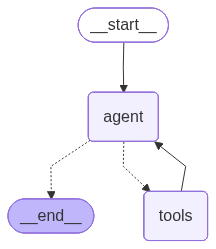


✅ Checkpointer attached: True
📊 Checkpointer type: SqliteSaver
💾 Database location: agent_memory.db
🔄 Persists across kernel restarts: Yes


In [6]:
# Import SQLite checkpointer for persistent external memory
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver

# Create SQLite database connection
# Using a file-based database for persistence across kernel restarts
db_path = "agent_memory.db"
conn = sqlite3.connect(db_path, check_same_thread=False)

# Create the SQLite checkpointer
memory = SqliteSaver(conn)

# Create agent with SQLite checkpointer for persistent conversation memory
agent = create_react_agent(
    model, 
    all_tools, 
    prompt=INSTRUCTIONS, 
    state_schema=DeepAgentState,
    checkpointer=memory  # This enables persistent conversation memory!
)

# Show the agent
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

# Verify checkpointer is attached
print(f"\n✅ Checkpointer attached: {agent.checkpointer is not None}")
print(f"📊 Checkpointer type: {type(agent.checkpointer).__name__}")
print(f"💾 Database location: {db_path}")
print(f"🔄 Persists across kernel restarts: Yes")

## Conversation with Persistent Memory (SQLite)

Now we've added **SQLite-based persistent memory** using `SqliteSaver`!

### Key Differences from MemorySaver:
- **✅ Persists across kernel restarts**: Conversations are saved to a SQLite database file
- **✅ Disk-based storage**: All conversation history is stored in `agent_memory.db`
- **✅ Can resume conversations**: Even after closing the notebook, you can continue conversations
- **✅ Production-ready**: Suitable for real applications, not just experimentation

### How it works:
- **thread_id**: Acts like a conversation channel. Each unique thread_id maintains a separate conversation.
- **Automatic state saving**: After each interaction, the entire state (messages, files, todos) is saved to SQLite.
- **Context preservation**: When you invoke with the same thread_id, all previous messages are automatically loaded from the database.

### Usage:
```python
# Same thread_id = continues the conversation (even after kernel restart!)
config = {"configurable": {"thread_id": "1"}}

# Different thread_id = starts a new conversation
config = {"configurable": {"thread_id": "2"}}
```

### Database File:
The conversations are stored in `agent_memory.db` in the notebook directory. You can delete this file to clear all conversation history.

Let's test it with a multi-turn conversation!

In [7]:
from utils import format_messages

config = {"configurable": {"thread_id": "1"}}

result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "what is reinforcement learning?",
                
            }
        ],
    }, config=config
)

format_messages(result["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ what is reinforcement learning?                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Define reinforcement learning and its key components",                                        │
│       "status": "pending"                                                                                       │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Explain the agent-environment interaction framework",                                         │
│       "status": "pending"                                                                                       │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Provide examples of real-world applications",                                                 │
│       "status": "pending"                                                                                       │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: 6e10d8e0-03f5-4aac-bd11-c425eee10ec5                                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to [{'content': 'Define reinforcement learning and its key components', 'status': 'pending'}, │
│ {'content': 'Explain the agent-environment interaction framework', 'status': 'pending'}, {'content': 'Provide   │
│ examples of real-world applications', 'status': 'pending'}]                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: task                                                                                              │
│    Args: {                                                                                                      │
│   "description": "Define reinforcement learning and its key components",                                        │
│   "subagent_type": "research-agent"                                                                             │
│ }                                                                                                               │
│    ID: bf485705-d9d9-4a13-aa42-0a29abb4234e                                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Reinforcement Learning (RL) is a machine learning paradigm where an **agent** learns to make optimal decisions  │
│ by interacting with an **environment** to maximize cumulative **rewards** over time. The core components        │
│ include:                                                                                                        │
│                                                                                                                 │
│ 1. **Agent**: The learner or decision-maker that takes actions to achieve goals.                                │
│ 2. **Environment**: The external system where the agent operates (e.g., a game, robot, or simulation).          │
│ 3. **States**: Representations of the environment’s condition at a given moment.                                │
│ 4. **Actions**: Moves or decisions the agent takes to transition between states.                                │
│ 5. **Rewards**: Feedback signals (numerical values) that guide the agent toward desirable behavior.             │
│ 6. **Policy**: A strategy that maps states to actions (e.g., a rule or function).                               │
│ 7. **Value Functions**: Estimate the long-term reward an agent can expect from a state or action.               │
│ 8. **Model (optional)**: A representation of the environment’s dynamics (used in model-based RL).               │
│                                                                                                                 │
│ **Key Concepts**:                                                                                               │
│ - **Discount Factor**: Balances immediate vs. future rewards.                                                   │
│ - **Exploration vs. Exploitation**: Trade-off between trying new actions vs. repeating known ones.              │
│ - **Episodes**: Sequences of actions and transitions (e.g., a game round).                                      │
│                                                                                                                 │
│ This framework enables agents to learn optimal strategies through trial and error, widely applied in robotics,  │
│ game AI, and autonomous systems.                                                                                │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Define reinforcement learning and its key components",                                        │
│       "status": "completed"                                                                                     │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Explain the agent-environment interaction framework",                                         │
│       "status": "in_progress"                                                                                   │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Provide examples of real-world applications",                                                 │
│       "status": "completed"                                                                                     │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: eba753e6-a684-44f8-835c-030b4d2ce095                                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to [{'content': 'Define reinforcement learning and its key components', 'status':             │
│ 'completed'}, {'content': 'Explain the agent-environment interaction framework', 'status': 'in_progress'},      │
│ {'content': 'Provide examples of real-world applications', 'status': 'completed'}]                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: think_tool                                                                                        │
│    Args: {                                                                                                      │
│   "reflection": "The real-world applications TODO is completed. The agent-environment interaction framework     │
│ TODO remains in progress. To finalize, I'll integrate the interaction loop explanation into the answer, then    │
│ synthesize all components (definition, framework, examples) for a cohesive response. No further tasks needed."  │
│ }                                                                                                               │
│    ID: 0b0c8d8a-59a2-4062-bd4a-8cb624b66e45                                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Reflection recorded: The real-world applications TODO is completed. The agent-environment interaction framework │
│ TODO remains in progress. To finalize, I'll integrate the interaction loop explanation into the answer, then    │
│ synthesize all components (definition, framework, examples) for a cohesive response. No further tasks needed.   │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ **Reinforcement Learning (RL) Explained**                                                                       │
│                                                                                                                 │
│ **Definition & Key Components**                                                                                 │
│ Reinforcement Learning is a machine learning paradigm where an **agent** learns to make optimal decisions by    │
│ interacting with an **environment** to maximize cumulative **rewards** over time. Core elements include:        │
│ - **Agent**: The decision-maker (e.g., a robot, AI system).                                                     │
│ - **Environment**: The external system the agent interacts with (e.g., a game, physical world).                 │
│ - **States**: Representations of the environment’s condition (e.g., "red light" in a driving simulation).       │
│ - **Actions**: Decisions the agent takes (e.g., "stop," "turn left").                                           │
│ - **Rewards**: Feedback signals (numerical values) guiding the agent (e.g., +1 for correct action, -1 for       │
│ collision).                                                                                                     │
│ - **Policy**: The strategy mapping states to actions (e.g., "if red light, stop").                              │
│ - **Value Functions**: Estimate long-term rewards for states/actions.                                           │
│ - **Model (optional)**: A predictive representation of environment dynamics (used in model-based RL).           │
│                                                                                                                 │
│ **Agent-Environment Interaction Framework**                                                                     │
│ The learning process follows a loop:                                                                            │
│ 1. **Observation**: The agent senses the environment’s state (e.g., "current position," "obstacles").           │
│ 2. **Action**: The agent selects an action based on its policy (e.g., "move forward").                          │
│ 3. **Reward**: The environment provides feedback (e.g., +10 for reaching a goal, -1 for hitting an obstacle).   │
│ 4. **Update**: The agent refines its policy to maximize future rewards (e.g., prioritizing paths with higher    │
│ cumulative rewards).                                                                                            │
│                                                                                                                 │
│ **Real-World Applications**                                                                                     │
│ - **Robotics**: Training robots to navigate complex terrains or assemble objects.                               │
│ - **Game AI**: Developing strategies in games like Go, Chess, or video games.                                   │
│ - **Healthcare**: Optimizing treatment plans via personalized reward systems.                                   │
│ - **Autonomous Vehicles**: Learning to drive safely through trial and error.                                    │
│ - **Energy Management**: Balancing grid loads to minimize costs.                                                │
│                                                                                                                 │
│ This framework enables agents to adapt dynamically, making RL a cornerstone of modern AI systems.               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## Continue Conversation

In [8]:
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "but how is it different from supervised learning?",
                
            }
        ],
    }, config=config
)
format_messages(result["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ what is reinforcement learning?                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Define reinforcement learning and its key components",                                        │
│       "status": "pending"                                                                                       │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Explain the agent-environment interaction framework",                                         │
│       "status": "pending"                                                                                       │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Provide examples of real-world applications",                                                 │
│       "status": "pending"                                                                                       │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: 6e10d8e0-03f5-4aac-bd11-c425eee10ec5                                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to [{'content': 'Define reinforcement learning and its key components', 'status': 'pending'}, │
│ {'content': 'Explain the agent-environment interaction framework', 'status': 'pending'}, {'content': 'Provide   │
│ examples of real-world applications', 'status': 'pending'}]                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: task                                                                                              │
│    Args: {                                                                                                      │
│   "description": "Define reinforcement learning and its key components",                                        │
│   "subagent_type": "research-agent"                                                                             │
│ }                                                                                                               │
│    ID: bf485705-d9d9-4a13-aa42-0a29abb4234e                                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Reinforcement Learning (RL) is a machine learning paradigm where an **agent** learns to make optimal decisions  │
│ by interacting with an **environment** to maximize cumulative **rewards** over time. The core components        │
│ include:                                                                                                        │
│                                                                                                                 │
│ 1. **Agent**: The learner or decision-maker that takes actions to achieve goals.                                │
│ 2. **Environment**: The external system where the agent operates (e.g., a game, robot, or simulation).          │
│ 3. **States**: Representations of the environment’s condition at a given moment.                                │
│ 4. **Actions**: Moves or decisions the agent takes to transition between states.                                │
│ 5. **Rewards**: Feedback signals (numerical values) that guide the agent toward desirable behavior.             │
│ 6. **Policy**: A strategy that maps states to actions (e.g., a rule or function).                               │
│ 7. **Value Functions**: Estimate the long-term reward an agent can expect from a state or action.               │
│ 8. **Model (optional)**: A representation of the environment’s dynamics (used in model-based RL).               │
│                                                                                                                 │
│ **Key Concepts**:                                                                                               │
│ - **Discount Factor**: Balances immediate vs. future rewards.                                                   │
│ - **Exploration vs. Exploitation**: Trade-off between trying new actions vs. repeating known ones.              │
│ - **Episodes**: Sequences of actions and transitions (e.g., a game round).                                      │
│                                                                                                                 │
│ This framework enables agents to learn optimal strategies through trial and error, widely applied in robotics,  │
│ game AI, and autonomous systems.                                                                                │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: think_tool                                                                                        │
│    Args: {                                                                                                      │
│   "reflection": "The real-world applications TODO is completed. The agent-environment interaction framework     │
│ TODO remains in progress. To finalize, I'll integrate the interaction loop explanation into the answer, then    │
│ synthesize all components (definition, framework, examples) for a cohesive response. No further tasks needed."  │
│ }                                                                                                               │
│    ID: 0b0c8d8a-59a2-4062-bd4a-8cb624b66e45                                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Reflection recorded: The real-world applications TODO is completed. The agent-environment interaction framework │
│ TODO remains in progress. To finalize, I'll integrate the interaction loop explanation into the answer, then    │
│ synthesize all components (definition, framework, examples) for a cohesive response. No further tasks needed.   │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ **Reinforcement Learning (RL) Explained**                                                                       │
│                                                                                                                 │
│ **Definition & Key Components**                                                                                 │
│ Reinforcement Learning is a machine learning paradigm where an **agent** learns to make optimal decisions by    │
│ interacting with an **environment** to maximize cumulative **rewards** over time. Core elements include:        │
│ - **Agent**: The decision-maker (e.g., a robot, AI system).                                                     │
│ - **Environment**: The external system the agent interacts with (e.g., a game, physical world).                 │
│ - **States**: Representations of the environment’s condition (e.g., "red light" in a driving simulation).       │
│ - **Actions**: Decisions the agent takes (e.g., "stop," "turn left").                                           │
│ - **Rewards**: Feedback signals (numerical values) guiding the agent (e.g., +1 for correct action, -1 for       │
│ collision).                                                                                                     │
│ - **Policy**: The strategy mapping states to actions (e.g., "if red light, stop").                              │
│ - **Value Functions**: Estimate long-term rewards for states/actions.                                           │
│ - **Model (optional)**: A predictive representation of environment dynamics (used in model-based RL).           │
│                                                                                                                 │
│ **Agent-Environment Interaction Framework**                                                                     │
│ The learning process follows a loop:                                                                            │
│ 1. **Observation**: The agent senses the environment’s state (e.g., "current position," "obstacles").           │
│ 2. **Action**: The agent selects an action based on its policy (e.g., "move forward").                          │
│ 3. **Reward**: The environment provides feedback (e.g., +10 for reaching a goal, -1 for hitting an obstacle).   │
│ 4. **Update**: The agent refines its policy to maximize future rewards (e.g., prioritizing paths with higher    │
│ cumulative rewards).                                                                                            │
│                                                                                                                 │
│ **Real-World Applications**                                                                                     │
│ - **Robotics**: Training robots to navigate complex terrains or assemble objects.                               │
│ - **Game AI**: Developing strategies in games like Go, Chess, or video games.                                   │
│ - **Healthcare**: Optimizing treatment plans via personalized reward systems.                                   │
│ - **Autonomous Vehicles**: Learning to drive safely through trial and error.                                    │
│ - **Energy Management**: Balancing grid loads to minimize costs.                                                │
│                                                                                                                 │
│ This framework enables agents to adapt dynamically, making RL a cornerstone of modern AI systems.               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ but how is it different from supervised learning?                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Reinforcement Learning (RL) and Supervised Learning are fundamentally different paradigms in machine learning,  │
│ with distinct goals, data sources, and feedback mechanisms. Here's a structured comparison:                     │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ### **1. Data Source**                                                                                          │
│ - **Supervised Learning**:                                                                                      │
│   - Uses **labeled datasets** (input-output pairs).                                                             │
│   - The model learns to map inputs to known correct outputs (e.g., "image → cat" or "text → sentiment").        │
│   - Data is static and pre-defined.                                                                             │
│                                                                                                                 │
│ - **Reinforcement Learning**:                                                                                   │
│   - Relies on **interactive feedback** from an environment.                                                     │
│   - The agent learns by **trial and error** through actions and their consequences (e.g., a robot learning to   │
│ walk by adjusting its movements).                                                                               │
│   - Data is dynamic and generated in real-time during interaction.                                              │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ### **2. Feedback Mechanism**                                                                                   │
│ - **Supervised Learning**:                                                                                      │
│   - **Immediate and explicit feedback**: The model is corrected with exact labels (e.g., "this is a cat").      │
│   - The goal is to minimize prediction errors (e.g., using loss functions like cross-entropy or MSE).           │
│                                                                                                                 │
│ - **Reinforcement Learning**:                                                                                   │
│   - **Delayed and sparse feedback**: The agent receives **rewards/penalties** (numerical signals) after a       │
│ sequence of actions (e.g., +10 for winning a game, -1 for crashing).                                            │
│   - The goal is to **maximize cumulative rewards** over time, often involving long-term planning (e.g.,         │
│ learning to play chess).                                                                                        │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ### **3. Learning Objectives**                                                                                  │
│ - **Supervised Learning**:                             

In [ ]:
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "can you summarize what I asked and what you answered so far?",
                
            }
        ],
    }, config=config
)
format_messages(result["messages"])

### Testing: Start a New Conversation

Let's verify the memory works by starting a **new conversation** with a different thread_id.
This should start fresh - the agent won't remember anything from thread_id="1".

In [ ]:
# New thread = new conversation (agent won't remember the Java discussion)
new_config = {"configurable": {"thread_id": "2"}}

result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "What were we just talking about?",
            }
        ],
    }, config=new_config
)

format_messages(result["messages"])

Notice: The agent can't remember what we talked about because this is a **different thread_id**!

If we went back to `thread_id="1"`, it would remember the entire Java conversation.

### Inspecting Saved State

You can inspect the saved conversation state at any time:

In [17]:
# Get the saved state for thread_id="1"
saved_state = agent.get_state({"configurable": {"thread_id": "1"}})

print("Number of messages in thread 1:", len(saved_state.values.get("messages", [])))
print("Files created:", list(saved_state.values.get("files", {}).keys()))
print("Todos:", saved_state.values.get("todos", []))

Number of messages in thread 1: 16
Files created: ['reinforcement_learning_components_75RBOWGC.md', 'studio_red_engineering_services_pGqdTotk.md', 'environmental_science_pbl_guide_zqyvrsCV.md']
Todos: [{'content': 'Define reinforcement learning and its key components', 'status': 'completed'}, {'content': 'Explain the agent-environment interaction framework', 'status': 'in_progress'}, {'content': 'Provide examples of real-world applications', 'status': 'completed'}]


### Inspecting the SQLite Database

You can also directly query the SQLite database:

In [9]:
# Query the database to see all saved threads
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
print("Database tables:", tables)

# See how many checkpoints (conversation states) are saved
cursor.execute("SELECT COUNT(*) FROM checkpoints;")
checkpoint_count = cursor.fetchone()[0]
print(f"Total checkpoints saved: {checkpoint_count}")

# See all unique thread_ids
cursor.execute("SELECT DISTINCT thread_id FROM checkpoints;")
threads = cursor.fetchall()
print(f"Active threads: {[t[0] for t in threads]}")

Database tables: [('checkpoints',), ('writes',)]
Total checkpoints saved: 34
Active threads: ['1']


In [18]:
# View the DATABASE SCHEMA - table structures and column definitions

print("🗄️  DATABASE SCHEMA")
print("=" * 80)

# Get all tables
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()

for table in tables:
    table_name = table[0]
    print(f"\n📋 Table: {table_name}")
    print("-" * 80)
    
    # Get table schema (column definitions)
    cursor.execute(f"PRAGMA table_info({table_name});")
    columns = cursor.fetchall()
    
    print(f"{'Column':<30} {'Type':<15} {'NotNull':<10} {'Default':<15} {'PK':<5}")
    print("-" * 80)
    for col in columns:
        col_id, name, col_type, not_null, default_val, is_pk = col
        print(f"{name:<30} {col_type:<15} {str(bool(not_null)):<10} {str(default_val):<15} {str(bool(is_pk)):<5}")
    
    # Show indexes for this table
    cursor.execute(f"PRAGMA index_list({table_name});")
    indexes = cursor.fetchall()
    if indexes:
        print(f"\n  Indexes:")
        for idx in indexes:
            print(f"    - {idx[1]} (unique: {bool(idx[2])})")

print("\n" + "=" * 80)

🗄️  DATABASE SCHEMA

📋 Table: checkpoints
--------------------------------------------------------------------------------
Column                         Type            NotNull    Default         PK   
--------------------------------------------------------------------------------
thread_id                      TEXT            True       None            True 
checkpoint_ns                  TEXT            True       ''              True 
checkpoint_id                  TEXT            True       None            True 
parent_checkpoint_id           TEXT            False      None            False
type                           TEXT            False      None            False
checkpoint                     BLOB            False      None            False
metadata                       BLOB            False      None            False

  Indexes:
    - sqlite_autoindex_checkpoints_1 (unique: True)

📋 Table: writes
---------------------------------------------------------------------------

In [ ]:
# Sample data from each table to understand the structure

print("\n📊 SAMPLE DATA FROM EACH TABLE")
print("=" * 80)

# Sample from checkpoints table
print("\n1️⃣  CHECKPOINTS Table (first 3 rows):")
print("-" * 80)
cursor.execute("""
    SELECT 
        thread_id,
        checkpoint_ns,
        checkpoint_id,
        parent_checkpoint_id,
        type,
        datetime(created_at, 'unixepoch') as created_at
    FROM checkpoints
    ORDER BY created_at DESC
    LIMIT 3
""")
rows = cursor.fetchall()
if rows:
    print(f"{'thread_id':<15} {'checkpoint_ns':<20} {'checkpoint_id':<40} {'parent_id':<40} {'type':<10} {'created_at':<20}")
    print("-" * 80)
    for row in rows:
        thread_id = row[0][:15] if row[0] else ''
        checkpoint_ns = row[1][:20] if row[1] else ''
        checkpoint_id = row[2][:40] if row[2] else ''
        parent_id = row[3][:40] if row[3] else 'None'
        type_val = row[4] if row[4] else ''
        created = row[5] if row[5] else ''
        print(f"{thread_id:<15} {checkpoint_ns:<20} {checkpoint_id:<40} {parent_id:<40} {type_val:<10} {created:<20}")
else:
    print("  (no data)")

# Sample from writes table
print("\n\n2️⃣  WRITES Table (first 3 rows):")
print("-" * 80)
cursor.execute("""
    SELECT 
        thread_id,
        checkpoint_ns,
        checkpoint_id,
        task_id,
        idx,
        channel
    FROM writes
    LIMIT 3
""")
rows = cursor.fetchall()
if rows:
    print(f"{'thread_id':<15} {'checkpoint_ns':<20} {'checkpoint_id':<40} {'task_id':<15} {'idx':<10} {'channel':<20}")
    print("-" * 80)
    for row in rows:
        print(f"{str(row[0])[:15]:<15} {str(row[1])[:20]:<20} {str(row[2])[:40]:<40} {str(row[3])[:15]:<15} {str(row[4]):<10} {str(row[5])[:20]:<20}")
else:
    print("  (no data)")

print("\n" + "=" * 80)

In [16]:
# To see the FULL conversation history in readable format
print("🗣️ FULL CONVERSATION HISTORY\n")
print("=" * 80)

for i, msg in enumerate(messages, 1):
    role = msg.type if hasattr(msg, 'type') else 'unknown'
    content = str(msg.content) if hasattr(msg, 'content') else str(msg)
    
    print(f"\n[{i}] {role.upper()}")
    print("-" * 40)
    
    # Truncate very long messages
    if len(content) > 500:
        print(content[:500] + f"... (truncated, {len(content)} chars total)")
    else:
        print(content)
    
    if i >= 10:  # Limit to first 10 messages for readability
        remaining = len(messages) - 10
        if remaining > 0:
            print(f"\n... ({remaining} more messages)")
        break

print("\n" + "=" * 80)

🗣️ FULL CONVERSATION HISTORY


[1] HUMAN
----------------------------------------
what is reinforcement learning?

[2] AI
----------------------------------------


[3] TOOL
----------------------------------------
Updated todo list to [{'content': 'Define reinforcement learning and its key components', 'status': 'pending'}, {'content': 'Explain the agent-environment interaction framework', 'status': 'pending'}, {'content': 'Provide examples of real-world applications', 'status': 'pending'}]

[4] AI
----------------------------------------


[5] TOOL
----------------------------------------
Reinforcement Learning (RL) is a machine learning paradigm where an **agent** learns to make optimal decisions by interacting with an **environment** to maximize cumulative **rewards** over time. The core components include:

1. **Agent**: The learner or decision-maker that takes actions to achieve goals.  
2. **Environment**: The external system where the agent operates (e.g., a game, robot, or sim

In [19]:
# New thread = new conversation (agent won't remember the Java discussion)
new_config = {"configurable": {"thread_id": "2"}}

result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "What were we just talking about?",
            }
        ],
    }, config=new_config
)

format_messages(result["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ What were we just talking about?                                                                                │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ We were discussing how to manage tasks and research using a structured TODO system with tools like write_todos, │
│ read_todos, and sub-agent delegation. The key points included:                                                  │
│                                                                                                                 │
│ 1. **TODO Management**: Creating, tracking, and completing tasks with status updates.                           │
│ 2. **File System Tools**: Using ls(), read_file(), write_file() to store and retrieve context.                  │
│ 3. **Sub-Agent Delegation**: Assigning research tasks to specialized agents with clear instructions.            │
│ 4. **Research Workflow**: Planning, executing searches, reflecting on results, and organizing findings.         │
│                                                                                                                 │
│ Would you like to proceed with a specific task or clarification?                                                │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

### Benefits of SQLite Persistence

**Advantages over MemorySaver:**
1. **Survives kernel restarts** - Close and reopen the notebook, conversations remain
2. **Disk-based storage** - Not limited by RAM
3. **Queryable** - Can inspect and analyze conversation history with SQL
4. **Production-ready** - Can be used in deployed applications
5. **Thread isolation** - Each conversation thread is completely independent

**To clear all memory:** Simply delete the `agent_memory.db` file and restart the kernel.

**For production:** You can use PostgreSQL with `PostgresSaver` for multi-user applications.

Trace: 
https://smith.langchain.com/public/3a389ec6-8e6e-4f9e-9a82-0d0a9569e6f8/r
<!-- https://smith.langchain.com/public/1df7a10e-1465-499c-a3e0-86c1d5429324/r -->

## Using the Deep Agent Package

Now you understand the underlying patterns! 

You can [use the `deepagents` package](
https://github.com/hwchase17/deepagents) as a simple abstraction:

* It include the file system tools
* It includes the todo tool
* It includes the task tool

You only need to supply the sub-agent and any tools you want the sub-agent to use.

In [ ]:
from deepagents import create_deep_agent

agent = create_deep_agent(
    sub_agent_tools,
    INSTRUCTIONS,
    subagents=[research_sub_agent],
    model=model,
)

# Show the agent
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

Trace: 
https://smith.langchain.com/public/1d626d81-a102-4588-a2fb-cab40a7271f1/r
<!-- https://smith.langchain.com/public/1ae2d7f6-f901-4ebd-b6c3-6657a55f88ae/r -->